In [1]:
%load_ext autoreload
%autoreload 2
from Environment import *
import numpy as np
import matplotlib.pyplot as plt

num_agents = 10                   
num_rounds = 200
num_episodes = 250
b = [2, 5, 10]           # Benefit
c = 1                    # Cost of cooperation

# Learning parameters   
chi = 0.01      # Reputation assignment error

In [2]:
def run(payoffs, norm):


    agents = [Qlearner(seeded=True) for _ in range(0)] + [Qlearner(seeded=False) for _ in range(10)]
    env = MatrixGame(payoffs, agents, norm)
    print("Norm:", env.norm)

    for episode in range(num_episodes):
        if episode%100==0:
            print(f"Number of episodes: {episode}")
        obs = env.reset()
        prev_obs = None
        prev_actions = {}
        prev_rewards = {}
        prev_opponents = {}
        for round in range(num_rounds):
            
            next_obs, rewards, actions = env.step()
            last_opponent = env.last_opponent
            if prev_obs is not None:
                for agent in agents:
                    s = prev_obs[prev_opponents[agent]]
                    a = prev_actions[agent]
                    r = prev_rewards[agent]
                    s_next = obs[last_opponent[agent]]
                    if round == num_rounds - 1:
                        agent.update(s, a, s_next, r, done=True)
                    else:
                        agent.update(s, a, s_next, r, done=False)
            prev_obs = obs
            prev_actions = actions
            prev_rewards = rewards
            prev_opponents = last_opponent
            obs = next_obs

    average_agent_round_payoff = np.zeros(num_episodes//2)
    for agent in agents:
        average_round_payoff = np.array(agent.episode_total_rewards[num_episodes//2:])/num_rounds
        average_agent_round_payoff += average_round_payoff

    b = payoffs[0,1]
    average_agent_round_payoff = (average_agent_round_payoff.sum()/(10*(num_episodes//2)))/(b-c)

    return average_agent_round_payoff

Norm: [1, 0, 0, 1]
Number of episodes: 0
Number of episodes: 100
Number of episodes: 200
Norm: [0, 0, 0, 0]
Number of episodes: 0
Number of episodes: 100
Number of episodes: 200
Norm: [1, 0, 0, 1]
Number of episodes: 0
Number of episodes: 100
Number of episodes: 200
Norm: [0, 0, 0, 0]
Number of episodes: 0
Number of episodes: 100
Number of episodes: 200
Norm: [1, 0, 0, 1]
Number of episodes: 0
Number of episodes: 100
Number of episodes: 200
Norm: [0, 0, 0, 0]
Number of episodes: 0
Number of episodes: 100
Number of episodes: 200


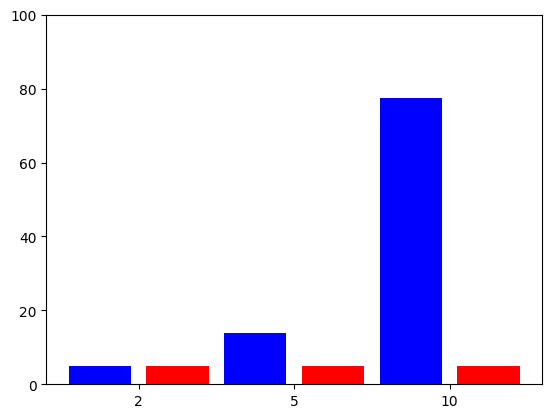

In [3]:
results = []
colors = ["blue", "red", "blue", "red", "blue", "red",]

effective_norm =[1,0,0,1]
ineffective_norm =[0,0,0,0]

payoffs = np.array([[0, b[0]],[-c, b[0]-c]])
results.append(run(payoffs, effective_norm))
results.append(run(payoffs, ineffective_norm))


payoffs = np.array([[0, b[1]],[-c, b[1]-c]])
results.append(run(payoffs, effective_norm))
results.append(run(payoffs, ineffective_norm))


payoffs = np.array([[0, b[2]],[-c, b[2]-c]])
results.append(run(payoffs, effective_norm))
results.append(run(payoffs, ineffective_norm))

results = np.array(results)
results *= 100

x = np.arange(len(results))

plt.figure()
plt.bar(range(len(results)), results.flatten(), color=colors)
plt.ylim(0,100)
pair_labels = ["2", "5", "10"]
pair_positions = [(x[i] + x[i+1])/2 for i in range(0, len(x), 2)]
plt.xticks(pair_positions, pair_labels)
plt.show()